# Density-Based Clustering using DBSCAN on the Country Socioeconomic Dataset

## Assignment Overview
This notebook is organized according to the assignment requirements.

## Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Countrydata.csv")

print("Shape:", df.shape)
print(df.head())
print(df.info())


print(df.isnull().sum())


print("Duplicates:", df.duplicated().sum())

Shape: (167, 10)
               country  child_mort  exports  health  imports  income  \
0          Afghanistan        90.2     10.0    7.58     44.9    1610   
1              Albania        16.6     28.0    6.55     48.6    9930   
2              Algeria        27.3     38.4    4.17     31.4   12900   
3               Angola       119.0     62.3    2.85     42.9    5900   
4  Antigua and Barbuda        10.3     45.5    6.03     58.9   19100   

   inflation  life_expec  total_fer   gdpp  
0       9.44        56.2       5.82    553  
1       4.49        76.3       1.65   4090  
2      16.10        76.5       2.89   4460  
3      22.40        60.1       6.16   3530  
4       1.44        76.8       2.13  12200  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   export

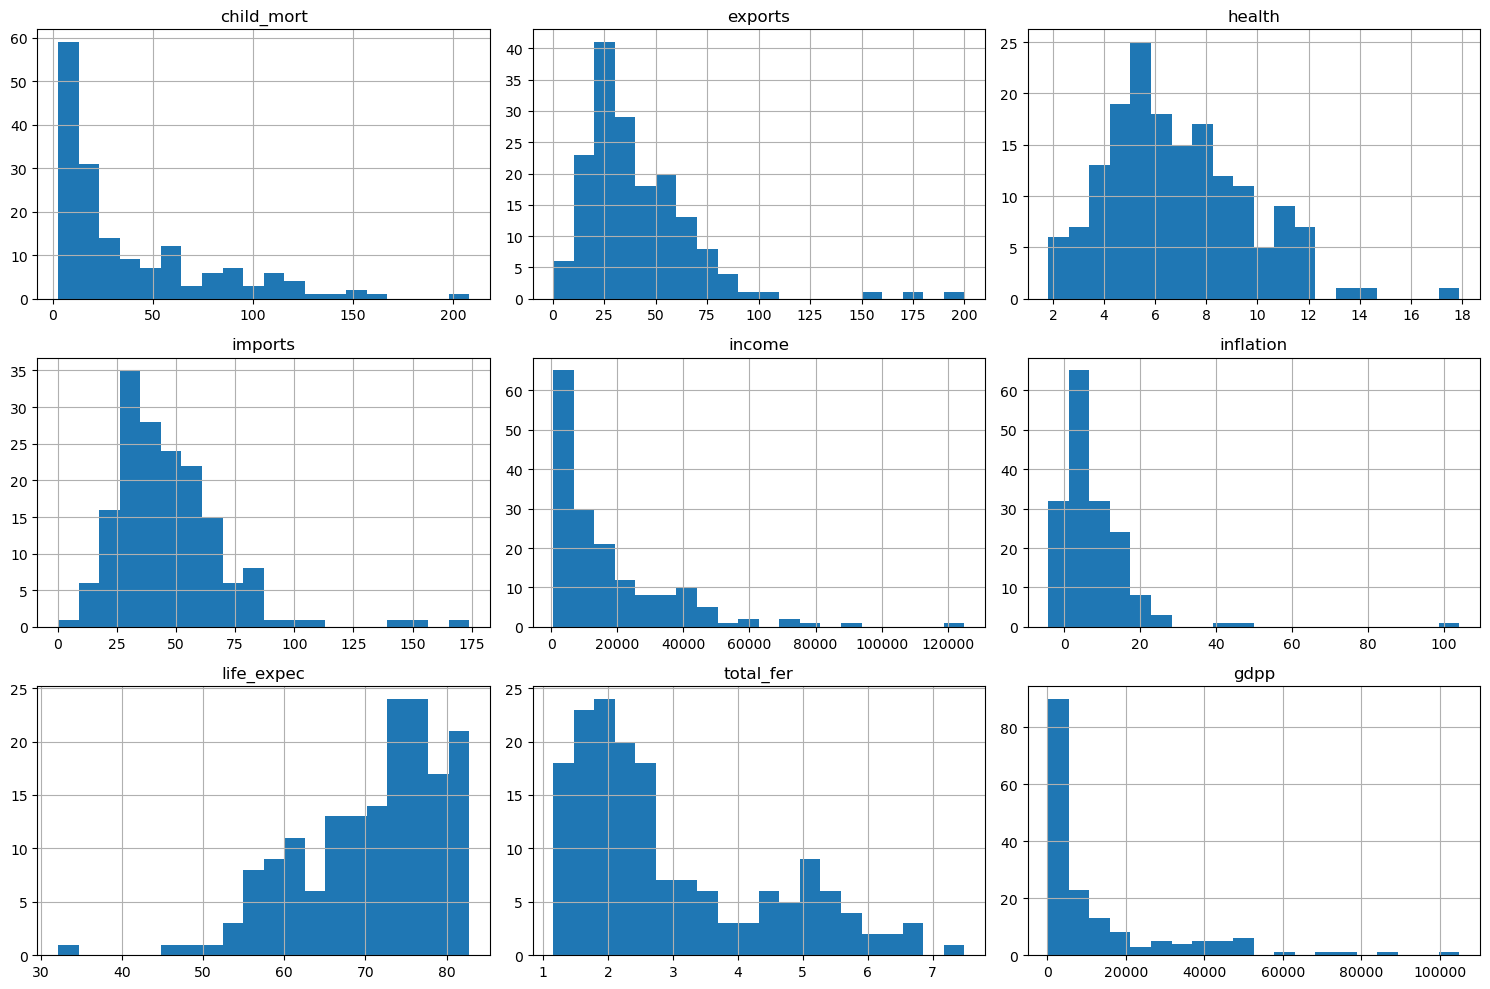

In [3]:
num_cols = df.columns[1:]

df[num_cols].hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

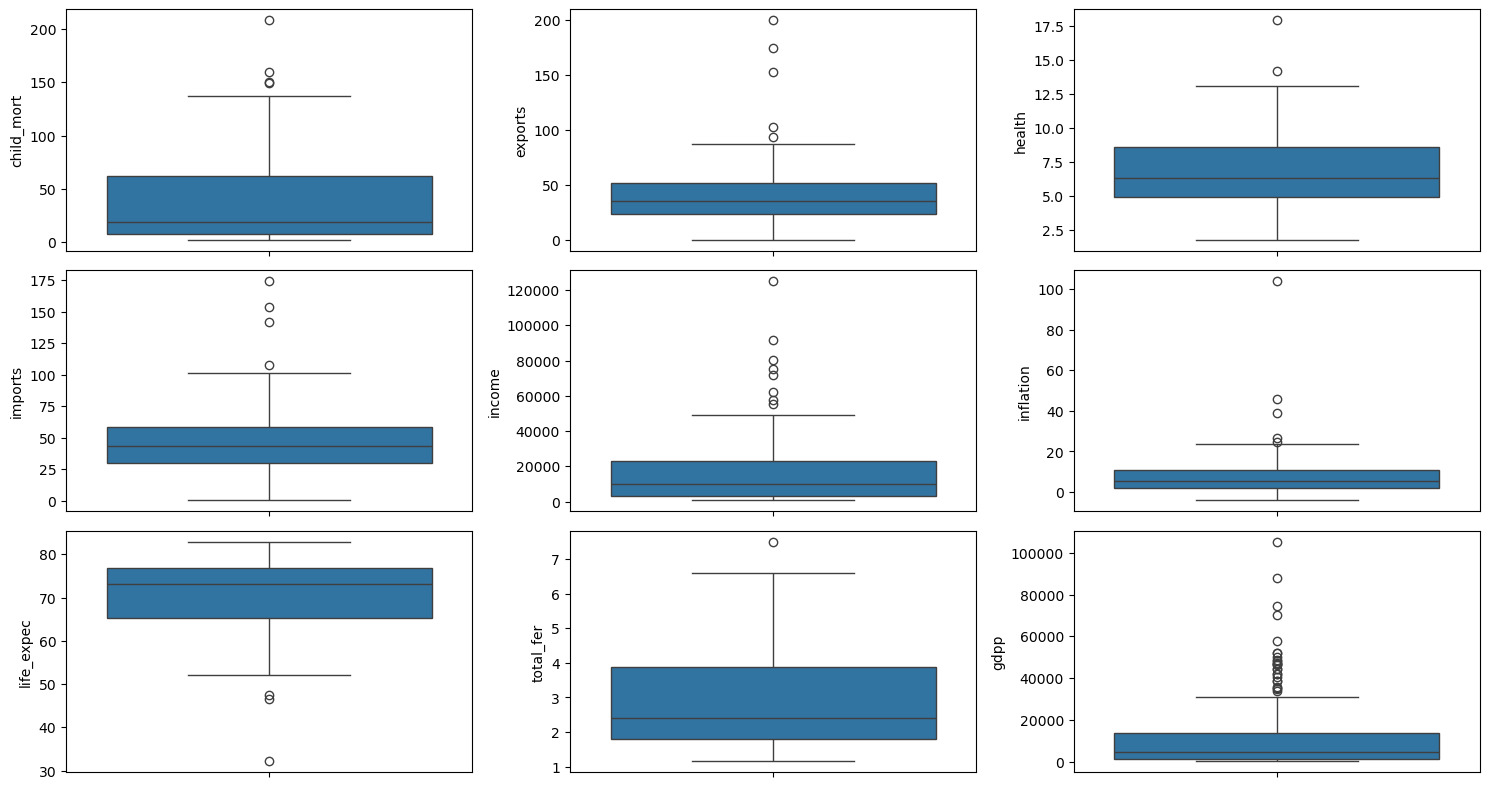

In [4]:
plt.figure(figsize=(15,8))

for i,col in enumerate(num_cols,1):
    plt.subplot(3,3,i)
    sns.boxplot(y=df[col])

plt.tight_layout()
plt.show()


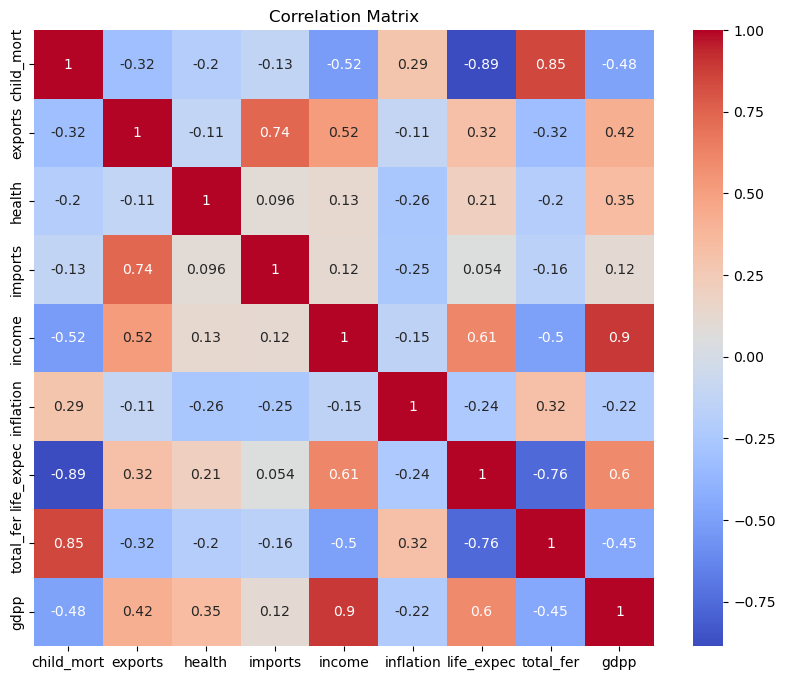

In [5]:
plt.figure(figsize=(10,8))

corr = df[num_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

## DATA PREPROSCESSING 

In [6]:
countries = df["country"]

X = df.drop("country", axis=1)

In [7]:
print(X.skew().sort_values(ascending=False))

inflation     5.154049
exports       2.445824
income        2.231480
gdpp          2.218051
imports       1.905276
child_mort    1.450774
total_fer     0.967092
health        0.705746
life_expec   -0.970996
dtype: float64


In [8]:
X["income"] = np.log1p(X["income"])
X["gdpp"] = np.log1p(X["gdpp"])

## Task 2: Data Preprocessing

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Hyperparameter Tuning

## Task 3: Hyperparameter Tuning

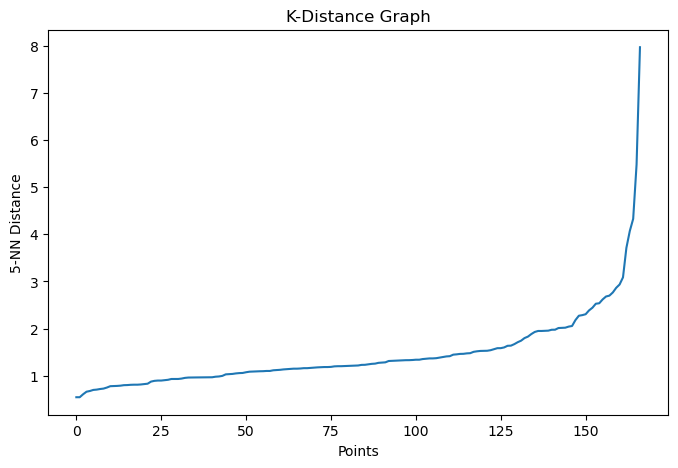

In [10]:
from sklearn.neighbors import NearestNeighbors

min_samples = 5

neighbors = NearestNeighbors(
    n_neighbors=min_samples
)

neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(8,5))
plt.plot(distances)

plt.xlabel("Points")
plt.ylabel("5-NN Distance")
plt.title("K-Distance Graph")
plt.show()

## Parameter Search

## Task 4: Applying DBSCAN Clustering

In [11]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

eps_values = [0.5, 0.8, 1.0]
min_samples_values = [4,5,8]

results = []

for eps in eps_values:

    for ms in min_samples_values:

        model = DBSCAN(
            eps=eps,
            min_samples=ms
        )

        labels = model.fit_predict(X_scaled)

        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

        noise = list(labels).count(-1)

        mask = labels != -1

        if len(set(labels[mask])) > 1:
            score = silhouette_score(
                X_scaled[mask],
                labels[mask]
            )
        else:
            score = np.nan

        results.append([
            eps,
            ms,
            n_clusters,
            noise,
            score
        ])

results_df = pd.DataFrame(
    results,
    columns=[
        "eps",
        "min_samples",
        "clusters",
        "noise",
        "silhouette"
    ]
)

print(results_df)

   eps  min_samples  clusters  noise  silhouette
0  0.5            4         1    162         NaN
1  0.5            5         0    167         NaN
2  0.5            8         0    167         NaN
3  0.8            4         3    133    0.285475
4  0.8            5         3    139    0.354338
5  0.8            8         1    155         NaN
6  1.0            4         3     96    0.289259
7  1.0            5         2    104    0.343599
8  1.0            8         2    125    0.431490


## FINAL DBSCAN MODEL

In [12]:
dbscan = DBSCAN(
    eps=0.8,
    min_samples=5
)

labels = dbscan.fit_predict(X_scaled)

df["Cluster"] = labels

## NUMBER OF CLUSTER

In [13]:
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)

noise_points = sum(labels == -1)

print("Clusters:", n_clusters)
print("Noise Points:", noise_points)

Clusters: 3
Noise Points: 139


## Countries per Cluster

In [14]:
for cluster in sorted(df["Cluster"].unique()):

    print("\nCluster:", cluster)

    print(
        df[df["Cluster"] == cluster]["country"]
        .tolist()
    )


Cluster: -1
['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahrain', 'Bangladesh', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bhutan', 'Bolivia', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei', 'Burkina Faso', 'Burundi', 'Cambodia', 'Cameroon', 'Cape Verde', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo, Dem. Rep.', 'Congo, Rep.', 'Costa Rica', "Cote d'Ivoire", 'Cyprus', 'Czech Republic', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Fiji', 'Gabon', 'Gambia', 'Georgia', 'Ghana', 'Grenada', 'Guatemala', 'Guinea', 'Guinea-Bissau', 'Guyana', 'Haiti', 'Hungary', 'India', 'Indonesia', 'Iran', 'Iraq', 'Ireland', 'Israel', 'Jamaica', 'Jordan', 'Kazakhstan', 'Kenya', 'Kiribati', 'Kuwait', 'Kyrgyz Republic', 'Lao', 'Lebanon', 'Lesotho', 'Liberia', 'Libya', 'Lithuania', 'Luxembourg', 'Madagascar', 'Malawi', 'Malaysia', 'Maldives', 'Mali', 'Malta', 'Maurit

## Silhouette Score

In [15]:
mask = labels != -1

score = silhouette_score(
    X_scaled[mask],
    labels[mask]
)

print(score)

0.35433803230791644


## PCA Visualization

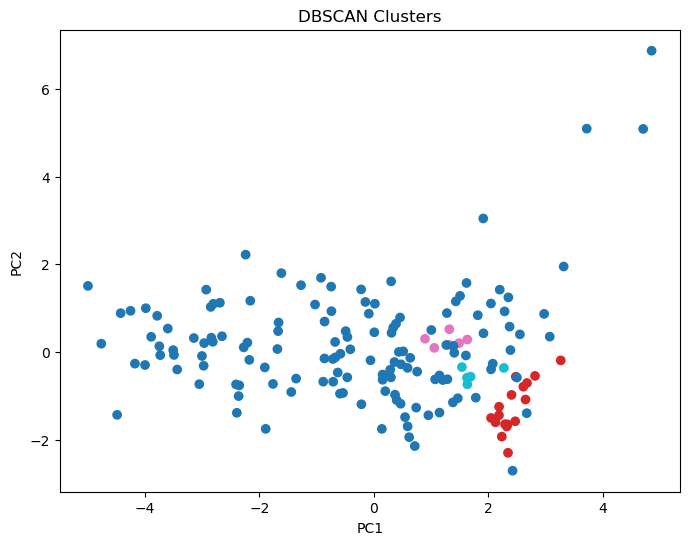

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=labels,
    cmap="tab10"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("DBSCAN Clusters")

plt.show()

## Noise Points in Black

## Task 5: Visualization

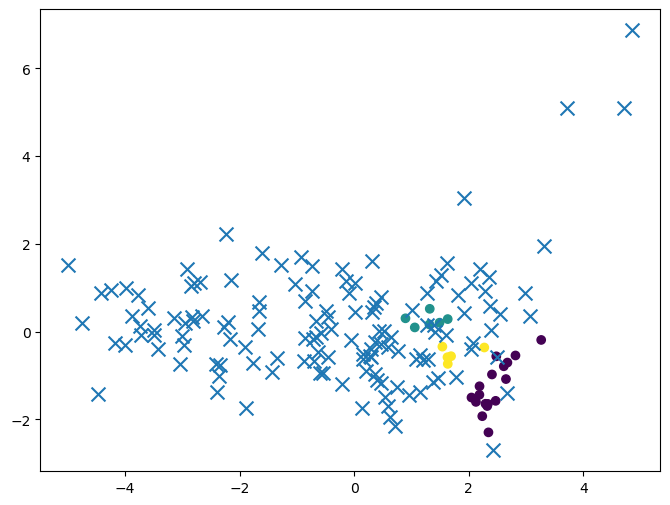

In [17]:
plt.figure(figsize=(8,6))

mask = labels == -1

plt.scatter(
    X_pca[~mask,0],
    X_pca[~mask,1],
    c=labels[~mask]
)

plt.scatter(
    X_pca[mask,0],
    X_pca[mask,1],
    marker='x',
    s=100
)

plt.show()